In [104]:
import sys
print(sys.executable)

c:\Users\ycode\Desktop\2nd_YouCode\briefs\Prediction_Prix_Immobilier\venv\Scripts\python.exe


# Jour 3 — Entraînement et comparaison de modèles

**Objectif :** entraîner plusieurs modèles de régression, les comparer avec RMSE/MAE/R², et sauvegarder le meilleur.

**Stratégie :**
- Target transformée en `log1p(SalePrice)` pour réduire l'asymétrie (skewness 2,55 → ~0)
- Métriques calculées en dollars (retour via `expm1`)
- 3 modèles testés : LinearRegression, RandomForestRegressor, GradientBoostingRegressor

In [105]:
# ===== Imports =====
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_style('whitegrid')

# ===== Chargement des artefacts du Jour 2 =====
X_train = joblib.load('../data/processed/X_train.pkl')
X_val   = joblib.load('../data/processed/X_val.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_val   = joblib.load('../data/processed/y_val.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

print("✅ Données chargées")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

# Vérification
assert X_train.shape == (1020, 209), f"Shape inattendue : {X_train.shape}"
assert X_val.shape   == (219, 209)
assert X_test.shape  == (219, 209)
assert y_train.shape == (1020,)
assert y_val.shape   == (219,)
assert y_test.shape  == (219,)
print("\n✅ Toutes les shapes sont correctes")

✅ Données chargées
X_train : (1020, 209)
X_val   : (219, 209)
X_test  : (219, 209)
y_train : (1020,)
y_val   : (219,)
y_test  : (219,)

✅ Toutes les shapes sont correctes


## 1. Transformation de la target

L'EDA a montré une skewness de **2,55** sur `SalePrice`. On applique `log1p` pour la réduire et améliorer les modèles linéaires. Les prédictions seront retransformées via `expm1` avant le calcul des métriques.

In [106]:
# ===== Transformation log1p =====
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f"Skewness SalePrice brut  : {y_train.skew():.4f}")
print(f"Skewness SalePrice log1p : {pd.Series(y_train_log).skew():.4f}")
print(f"\nStatistiques (log1p) :")
print(f"  min    : {y_train_log.min():.4f}")
print(f"  max    : {y_train_log.max():.4f}")
print(f"  mean   : {y_train_log.mean():.4f}")
print(f"  median : {np.median(y_train_log):.4f}")

Skewness SalePrice brut  : 1.9024
Skewness SalePrice log1p : 0.1728

Statistiques (log1p) :
  min    : 10.4603
  max    : 13.5345
  mean   : 12.0279
  median : 12.0076


## 2. Fonction d'évaluation

Fonction réutilisable qui :
1. Entraîne le modèle sur `X_train` / `y_train_log`
2. Prédit sur `X_val`
3. Retransforme en dollars via `expm1`
4. Calcule RMSE, MAE, R² **en dollars**
5. Retourne un dictionnaire de résultats

In [107]:
def evaluate_model(model, X_tr, y_tr_log, X_v, y_v_log, 
                   y_v_real, name="Model"):
    """
    Entraîne et évalue un modèle. Retourne un dict de résultats.
    Les métriques sont calculées en dollars (target retransformée).
    """
    # Entraînement (sur target log1p)
    model.fit(X_tr, y_tr_log)
    
    # Prédiction (target log1p)
    y_pred_log = model.predict(X_v)
    
    # Retour en dollars
    y_pred_dollars = np.expm1(y_pred_log)
    
    # Métriques en dollars
    mse  = mean_squared_error(y_v_real, y_pred_dollars)
    rmse = np.sqrt(mean_squared_error(y_v_real, y_pred_dollars))
    mae  = mean_absolute_error(y_v_real, y_pred_dollars)
    r2   = r2_score(y_v_real, y_pred_dollars)
    
    print(f"{name:25s} |  MSE: {mse:>10,.0f} $ |  RMSE: {rmse:>10,.0f} $ | MAE: {mae:>10,.0f} $ | R²: {r2:.4f}")
    
    return {
        "model": name,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "fitted": model
    }


def plot_predictions(model, X_v, y_v_real, name="Model"):
    """Affiche un nuage de points Réel vs Prédit et la distribution des erreurs."""
    y_pred_log = model.predict(X_v)
    y_pred = np.expm1(y_pred_log)
    residuals = y_v_real - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Réel vs Prédit
    axes[0].scatter(y_v_real, y_pred, alpha=0.7, color="royalblue")
    min_val = min(y_v_real.min(), y_pred.min())
    max_val = max(y_v_real.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='y=x')
    axes[0].set_xlabel('Prix réel')
    axes[0].set_ylabel('Prix prédit')
    axes[0].set_title(f'{name} - Réel vs Prédit')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Distribution des erreurs
    axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Erreur (réel - prédit)')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title(f'{name} - Distribution des erreurs')

    plt.tight_layout()
    plt.show()


# Liste qui va accumuler les résultats
results = []
print("Fonction prête ✅")

Fonction prête ✅


## 3. ÉTAPE A — Baseline : LinearRegression

Modèle de référence. Tous les autres modèles doivent le battre.

ÉTAPE A — Baseline (LinearRegression)
LinearRegression          |  MSE: 555,648,097 $ |  RMSE:     23,572 $ | MAE:     16,740 $ | R²: 0.8976


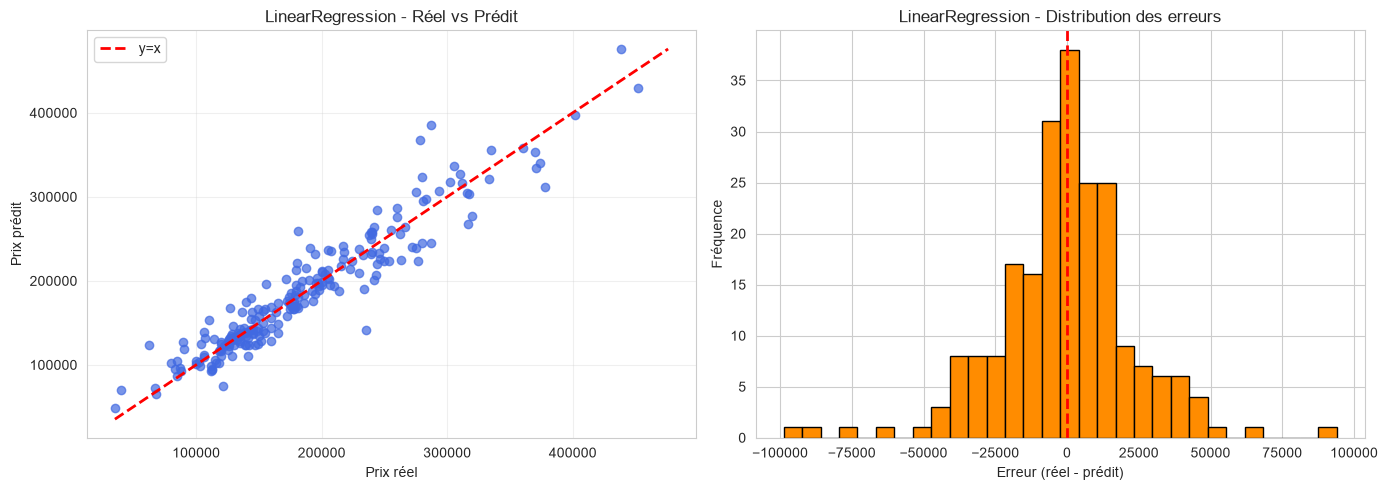

In [108]:
print("=" * 80)
print("ÉTAPE A — Baseline (LinearRegression)")
print("=" * 80)

model = LinearRegression()
result = evaluate_model(
    model,
    X_train, y_train_log,
    X_val,   y_val_log,
    y_v_real=y_val,
    name="LinearRegression"
)
results.append(result)
plot_predictions(model, X_val, y_val, "LinearRegression")

## 4. ÉTAPE B — Modèle basé sur les arbres

- **RandomForestRegressor** : ensemble d'arbres, robuste aux non-linéarités
- Capture des interactions entre variables sans besoin d'un modèle linéaire
- Très bon compromis entre flexibilité et stabilité

ÉTAPE B — Modèle basé sur les arbres
RandomForest              |  MSE: 490,643,534 $ |  RMSE:     22,150 $ | MAE:     16,007 $ | R²: 0.9096


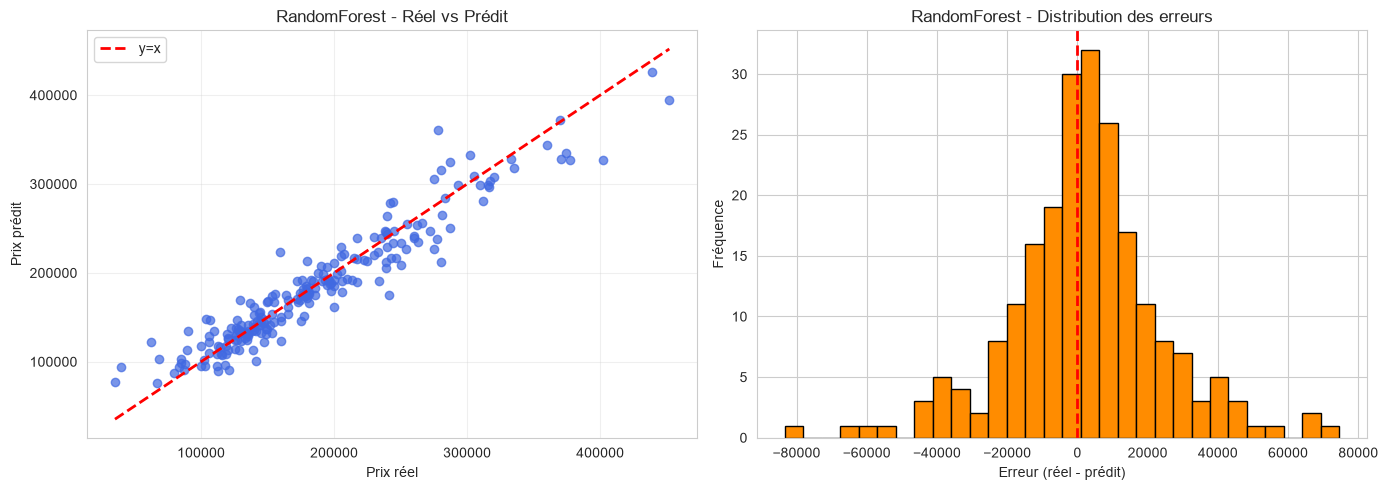

In [109]:
print("=" * 80)
print("ÉTAPE B — Modèle basé sur les arbres")
print("=" * 80)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
result = evaluate_model(
    model,
    X_train, y_train_log, X_val, y_val_log, y_val,
    name="RandomForest"
)
results.append(result)
plot_predictions(model, X_val, y_val, "RandomForest")

## 5. ÉTAPE C — Modèle non linéaire

- **GradientBoostingRegressor** : boosting séquentiel qui corrige les erreurs successives
- Très performant sur les jeux tabulaires comme l'immobilier
- Capturer les relations complexes entre variables et le prix

ÉTAPE C — Modèle non linéaire
GradientBoosting          |  MSE: 409,347,385 $ |  RMSE:     20,232 $ | MAE:     15,281 $ | R²: 0.9246


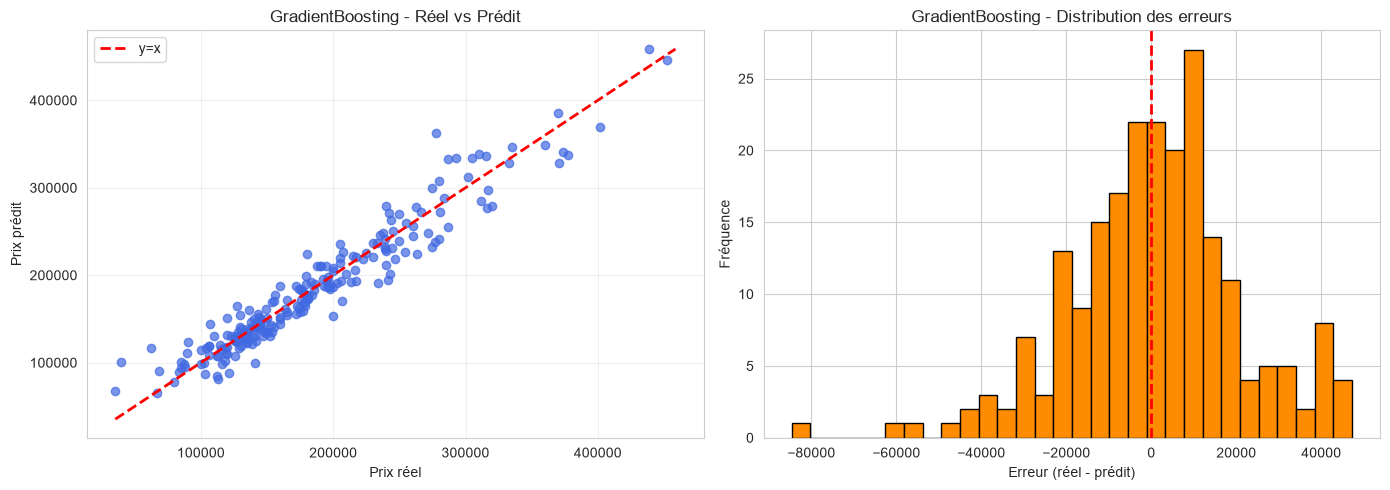

In [110]:
print("=" * 80)
print("ÉTAPE C — Modèle non linéaire")
print("=" * 80)

model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
result = evaluate_model(
    model,
    X_train, y_train_log, X_val, y_val_log, y_val,
    name="GradientBoosting"
)
results.append(result)
plot_predictions(model, X_val, y_val, "GradientBoosting")

## 6. ÉTAPE D — Comparaison des modèles

ÉTAPE D — Tableau comparatif
           model              mse     rmse      mae     r2
GradientBoosting 409,347,385.4657 20,232 $ 15,281 $ 0.9246
    RandomForest 490,643,534.3798 22,150 $ 16,007 $ 0.9096
LinearRegression 555,648,097.1704 23,572 $ 16,740 $ 0.8976


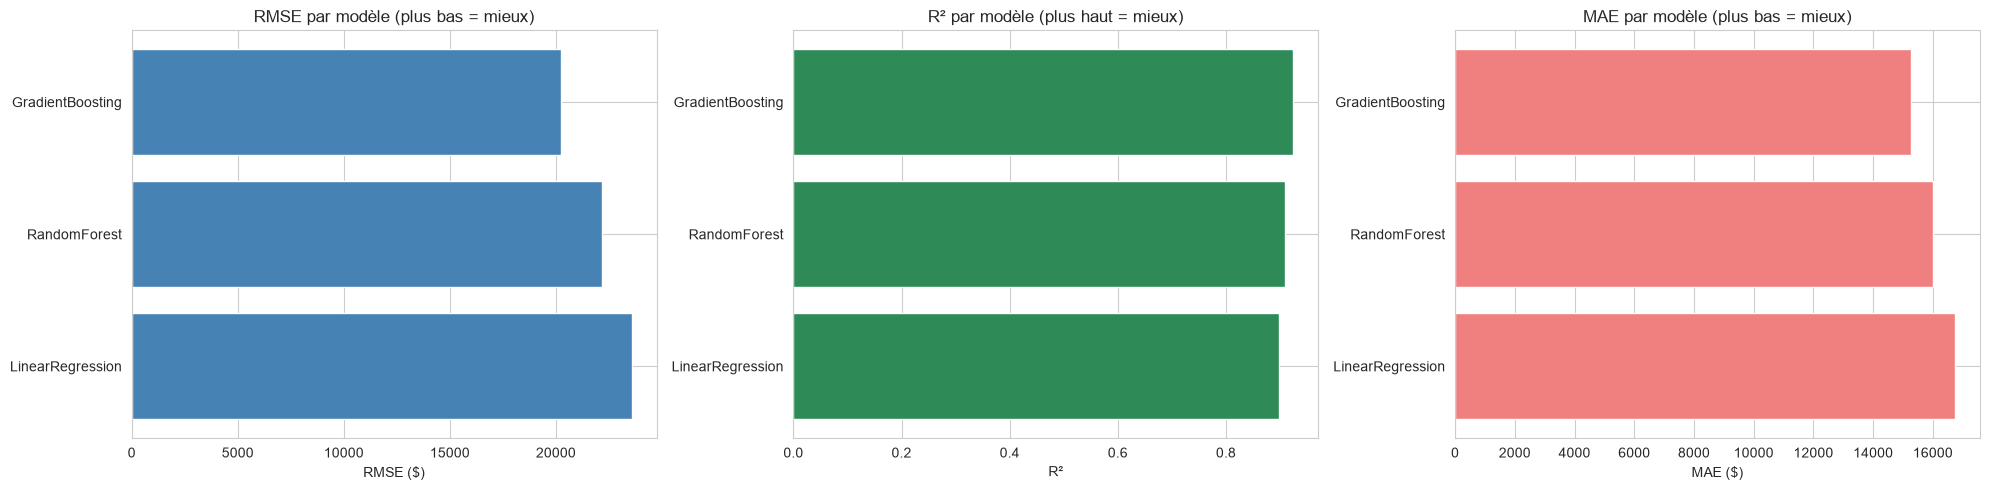

In [111]:
print("=" * 80)
print("ÉTAPE D — Tableau comparatif")
print("=" * 80)

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fitted"}
    for r in results
]).sort_values("rmse").reset_index(drop=True)

df_results["rmse"] = df_results["rmse"].map(lambda x: f"{x:,.0f} $")
df_results["mae"]  = df_results["mae"].map(lambda x: f"{x:,.0f} $")
df_results["r2"]   = df_results["r2"].map(lambda x: f"{x:.4f}")

print(df_results.to_string(index=False))

# Visualisation des trois métriques
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

rmse_vals = [r["rmse"] for r in results]
r2_vals   = [r["r2"]   for r in results]
mae_vals  = [r["mae"]  for r in results]
names     = [r["model"] for r in results]

# Tri par RMSE croissant
order = np.argsort(rmse_vals)
names_sorted = [names[i] for i in order]
rmse_sorted  = [rmse_vals[i] for i in order]
mae_sorted   = [mae_vals[i] for i in order]
r2_sorted    = [r2_vals[i] for i in order]

axes[0].barh(names_sorted, rmse_sorted, color='steelblue')
axes[0].set_xlabel("RMSE ($)")
axes[0].set_title("RMSE par modèle (plus bas = mieux)")
axes[0].invert_yaxis()

axes[1].barh(names_sorted, r2_sorted, color='seagreen')
axes[1].set_xlabel("R²")
axes[1].set_title("R² par modèle (plus haut = mieux)")
axes[1].invert_yaxis()

axes[2].barh(names_sorted, mae_sorted, color='lightcoral')
axes[2].set_xlabel("MAE ($)")
axes[2].set_title("MAE par modèle (plus bas = mieux)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Sauvegarde du meilleur modèle

On garde le modèle avec le plus faible RMSE.

In [112]:
best = min(results, key=lambda r: r["rmse"])

print("=" * 80)
print(f"🏆 MEILLEUR MODÈLE : {best['model']}")
print("=" * 80)
print(f"RMSE : {best['rmse']:,.0f} $")
print(f"MAE  : {best['mae']:,.0f} $")
print(f"R²   : {best['r2']:.4f}")

# Sauvegarde
model_filename = f"best_model_{best['model'].replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')}.pkl"
model_path = f"../models/{model_filename}"

joblib.dump(best["fitted"], model_path)
print(f"\n💾 Modèle sauvegardé : {model_path}")

# Sauvegarde aussi des résultats
df_export = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fitted"} for r in results
])
df_export.to_csv("../models/model_comparison.csv", index=False)
print("💾 Comparaison sauvegardée : models/model_comparison.csv")

🏆 MEILLEUR MODÈLE : GradientBoosting
RMSE : 20,232 $
MAE  : 15,281 $
R²   : 0.9246

💾 Modèle sauvegardé : ../models/best_model_GradientBoosting.pkl
💾 Comparaison sauvegardée : models/model_comparison.csv


## 8. Évaluation finale sur le jeu de test

Le modèle est sélectionné sur la validation, puis réentraîné sur train + validation avant une seule évaluation sur le test indépendant.

In [113]:
# ===== Évaluation finale sur test indépendant =====
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)
y_train_final_log = np.log1p(y_train_final)

final_model = type(best["fitted"])(**best["fitted"].get_params())
final_model.fit(X_train_final, y_train_final_log)

y_test_pred = np.expm1(final_model.predict(X_test))
final_metrics = {
    "model": best["model"],
    "rmse": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    "mae": mean_absolute_error(y_test, y_test_pred),
    "r2": r2_score(y_test, y_test_pred),
}

print("=" * 80)
print("ÉVALUATION FINALE — TEST INDÉPENDANT")
print("=" * 80)
print(f"Modèle : {final_metrics['model']}")
print(f"RMSE   : {final_metrics['rmse']:,.0f} $")
print(f"MAE    : {final_metrics['mae']:,.0f} $")
print(f"R²     : {final_metrics['r2']:.4f}")

final_model_path = f"../models/final_model_{best['model']}.pkl"
joblib.dump(final_model, final_model_path)
pd.DataFrame([final_metrics]).to_csv('../models/final_test_metrics.csv', index=False)
print(f"\n💾 Modèle final sauvegardé : {final_model_path}")
print("💾 Métriques finales sauvegardées : models/final_test_metrics.csv")

ÉVALUATION FINALE — TEST INDÉPENDANT
Modèle : GradientBoosting
RMSE   : 21,738 $
MAE    : 13,790 $
R²     : 0.9227

💾 Modèle final sauvegardé : ../models/final_model_GradientBoosting.pkl
💾 Métriques finales sauvegardées : models/final_test_metrics.csv


## 9. Cross-validation sur le train

La validation croisée est réalisée uniquement sur le jeu d'entraînement. Le jeu de test reste indépendant.

In [114]:
print("=" * 80)
print("Cross-validation 5-fold (sur train uniquement)")
print("=" * 80)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for model, name in [
    (LinearRegression(), "LinearRegression"),
    (RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1), "RandomForest"),
    (GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42), "GradientBoosting")
]:
    scores = cross_val_score(
        model, X_train, y_train_log,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    rmse_cv = -scores
    print(f"{name:25s} | CV RMSE (log) : {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")

Cross-validation 5-fold (sur train uniquement)
LinearRegression          | CV RMSE (log) : 0.1378 ± 0.0109
RandomForest              | CV RMSE (log) : 0.1376 ± 0.0040
GradientBoosting          | CV RMSE (log) : 0.1275 ± 0.0063
